In [1]:
#Array packages
import pandas as pd
import numpy as np
import xarray as xr
import netCDF4 as nc4

from scipy.stats import kendalltau
import pymannkendall as mk

#plots
import matplotlib.pyplot as plt
import rioxarray as rio
import geopandas as gpd
from shapely.geometry import mapping
import cartopy.crs as ccrs

#Progress meter
from dask.diagnostics import ProgressBar
from tqdm import tqdm

# Directories
import os
import glob
import dask
#import h5netcdf
import scipy

import scipy.stats as stats
import matplotlib.pyplot as plt

import os
#os.chdir(r"E:\academy\OneDrive - IIT Delhi\3. IIT DELHI\2. Research\2_Papers\1_Clustering connectivity")
os.chdir(r"G:\OneDrive - IIT Delhi\3. IIT DELHI\2. Research\2_Papers\1_Clustering connectivity")
print(os.getcwd())

G:\OneDrive - IIT Delhi\3. IIT DELHI\2. Research\2_Papers\1_Clustering connectivity


## 1. DATA preprocessing

In [4]:
gauge_info=pd.read_csv(r"3_Data/Data_p/2_Station/1_Streamflow_data/gauge_info_p.csv")
gauge_info['Period_length']=gauge_info['Expected_entries']/365

# Final criteria
yr_strt=1980;yr_end=2020
period=22; miss_prc=4
gauge_final=gauge_info.loc[(gauge_info['Period_length']>period) & (gauge_info['missing_percent']<miss_prc)]
gauge_final.reset_index(drop=True,inplace=True)

gauge_final.to_csv(f'3_Data/Data_p/2_Station/1_Streamflow_data/gauge_info_p.csv') 

for g,stn in enumerate(gauge_final['GaugeID'].values):

    data1=pd.read_csv(f'3_Data/Data_p/2_Station/1_Streamflow_data/{stn}.csv',index_col=0,parse_dates=True) 
    nan_years = data1.groupby(data1.index.year)['Streamflow (cumecs)'].apply(lambda x: x.isna().all())
    nan_years=nan_years[nan_years].index.to_list()
    #data1=data1.interpolate(method='linear')
    data1.to_csv(f'3_Data/Data_p/2_Station/2_Streamflow_interpolated/{stn}.csv') 
    



# 2. Flood Identification-run theory


In [44]:
th=98.5
#data1=pd.read_csv(f'3_Data/Data_p/2_Station/2_Streamflow_interpolated/{stn}.csv',index_col=0,parse_dates=True) interpolated data
data1=pd.read_csv(f'3_Data/Data_p/2_Station/1_Streamflow_data/{stn}.csv',index_col=0,parse_dates=True)  
np.percentile(data1['Streamflow (cumecs)'].dropna(),th)

data1['exceedence']=(data1['Streamflow (cumecs)']>np.percentile(data1['Streamflow (cumecs)'],th)).astype(int)
data1['change point']=data1['exceedence'].diff().fillna(0)
data1

,Streamflow (cumecs),exceedence,change point
Date,,,
1989-07-13,64.53,0,0.0
1989-07-14,183.90,0,0.0
1989-07-15,219.70,0,0.0
1989-07-16,1937.00,0,0.0
1989-07-17,2684.00,0,0.0
...,...,...,...
2019-02-02,NaN,0,0.0
2019-02-03,NaN,0,0.0
2019-02-04,NaN,0,0.0


In [12]:

for s,stn in enumerate(gauge_final['GaugeID'].values):
        
    th=99
    data1=pd.read_csv(f'3_Data/Data_p/2_Station/2_Streamflow_interpolated/{stn}.csv',index_col=0,parse_dates=True) #interpolated data
    #data1=pd.read_csv(f'3_Data/Data_p/2_Station/1_Streamflow_data/{stn}.csv',index_col=0,parse_dates=True)  
    th_value=np.nanpercentile(data1['Streamflow (cumecs)'].dropna(),th)

    data1['exceedence']=(data1['Streamflow (cumecs)']>th_value).astype(int)
    data1['change point']=data1['exceedence'].diff().fillna(0)


    data1['flood start']=data1['change point']==1
    data1['event']=data1['flood start'].cumsum()

    floods=data1[data1['exceedence']==1]
    flood_events=floods.groupby('event')


    results = []
    for event, group in flood_events:
        start = group.index[0]
        end = group.index[-1]
        duration = (end - start).days+1
        peak = group['Streamflow (cumecs)'].max()
        peak_date = group['Streamflow (cumecs)'].idxmax() 
        severity = group['Streamflow (cumecs)'].sum()
        
        results.append([start, end, duration,severity, peak,peak_date])


    flood_summary = pd.DataFrame(results, columns=['Start', 'End', 'Duration (days)','Severity', 'Peak Flow','Peak Date'])
    flood_summary.to_csv(f'3_Data/Data_p/5_flood events/{stn}.csv') 



    # Handling dependent events (Event occuring in a few days gap)
    
    th_day=15
    flood_summary["Gap (days)"] = flood_summary["Start"]-flood_summary["End"].shift(1) #Calculate gap between consecutive events
    flood_summary["Gap (days)"] = flood_summary["Gap (days)"].dt.days  # Convert to integer days
    flood_summary['Gap binary'] = (flood_summary["Gap (days)"] < th_day).astype(int)
    flood_summary["Group"] = (flood_summary["Gap binary"] == 0).cumsum()
    merged_floods = flood_summary.groupby("Group").agg({
        "Start": "min",  # Earliest start date in the group
        "End": "max",  # Latest end date in the group
        "Duration (days)": "sum",  # Sum durations
        "Severity": "sum",  # Sum severities
        "Peak Flow": "max",  # Max peak flow in the group
        "Peak Date": "min"  # Earliest peak date in the group
    }).reset_index()

    merged_floods=merged_floods.iloc[0:-1,0:7]
    merged_floods.to_csv(f'3_Data/Data_p/5_flood events/independand/{stn}.csv') 




# 2 PLOTs

### 2.1 Map

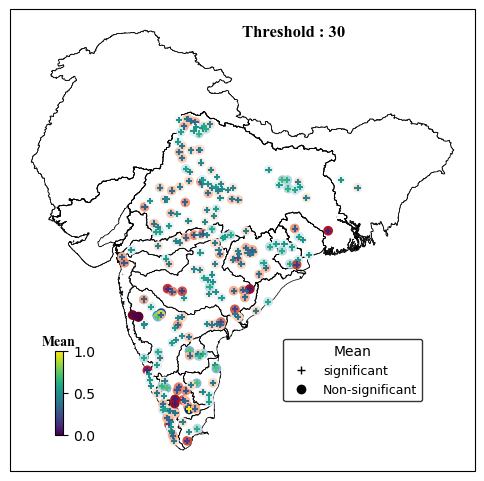

In [263]:
import matplotlib.lines as mlines

perc=[f"P{thr[i]}" for i in range(len(thr))]

south_asia=gpd.read_file(r'3_Data\Data_p\3_Shapefiles\south_asia_p.shp')

p=perc[4]



fig,ax1 = plt.subplots(1,1,figsize=(6,6),subplot_kw={'projection': ccrs.PlateCarree()})

south_asia.plot(ax=ax1,color='none',edgecolor='black',linewidth=0.55,alpha=0.9)
ax1.scatter(result_ks['Longitude'],result_ks['Latitude'],c=result_mean[p],cmap='RdBu')


bins = [0, 0.05 ,2]
marker1 = ['+', 'o']
result_ks['marker'] = pd.cut(result_ks[p], bins=bins, labels=marker1)
scatter_plots = []
for marker_type, label in zip(marker1, ["significant", "Non-significant"]):
    subset = result_ks[result_ks['marker'] == marker_type]
    sc=ax1.scatter(subset['Longitude'],subset['Latitude'],c=result_mean.loc[subset.index,p],cmap='viridis',marker=marker_type,s=20)
    scatter_plots.append(mlines.Line2D([], [], color='black', marker=marker_type, linestyle='None', markersize=6, label=label))



cbar_ax = fig.add_axes([0.2, 0.17, 0.014, 0.14])
cbar = plt.colorbar(sc, cax=cbar_ax, orientation='vertical', fraction=0.03, pad=0.02)
cbar.ax.set_xlabel('Mean', fontsize=10, fontname='Times New Roman',weight='bold')
cbar.ax.xaxis.set_label_position('top')


ax1.text(0.50, 0.95, f'Threshold : {p[1:]}', fontsize=12, color='black',fontname='Times New Roman',weight='bold',
transform=ax1.transAxes, ha='left', va='center')


ax1.legend(handles=scatter_plots, title="Mean", title_fontsize=10, fontsize=9, frameon=True, edgecolor='black', bbox_to_anchor=(0.9, 0.3))



#plt.savefig(fr'22_Analysis\2_Distribution_check\Outputs\{p}', bbox_inches='tight',dpi=1000)

# FUNCTIONS

### 1. Station visualization

In [6]:

def Station_Map(data,condition):

    #data=pd.read_csv(r"3_Data\Data_p\2_Station\1_Streamflow_data\data.csv")
    south_asia=gpd.read_file(r'3_Data\Data_p\3_Shapefiles\south_asia_p.shp')
 
    fig, ax1 = plt.subplots(1, 1, figsize=(6,6), subplot_kw={"projection": ccrs.PlateCarree()})
    south_asia.plot(ax=ax1,color = 'none',edgecolor = 'black',linewidth=0.55,alpha=0.9)

    #Axis setting
    [x.set_visible(False) for x in ax1.spines.values()]
    [x.set_linewidth(0.2) for x in ax1.spines.values()]

    c1=np.repeat(['Blue'],len(data['Latitude']))
    sc=ax1.scatter(data['Longitude'],data['Latitude'],c='firebrick',s=13,edgecolor='black')

    ax1.text(0.50, 0.95, 'Stations : Full', fontsize=12, color='black',fontname='Times New Roman',weight='bold',
    transform=ax1.transAxes, ha='left', va='center')

    ax1.text(0.5, 0.9, f'No of Station : {len(data)}' , fontsize=12, color='black',fontname='Times New Roman',weight='bold',
    transform=ax1.transAxes, ha='left', va='center')


